# Modelos No Supervisados - Métodos de Clustering

# Caso -> **"Clustering de distritos"**

## wd

In [101]:
### Mounting Google Drive :
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
!pwd

/content/drive/My Drive/_PUCP_s/Cursos/1INF03_ADD/datos


In [103]:
working_dir = "/content/drive/MyDrive/_PUCP_s/Cursos/1INF03_ADD/datos"
%cd $working_dir

/content/drive/MyDrive/_PUCP_s/Cursos/1INF03_ADD/datos


In [104]:
!pwd

/content/drive/MyDrive/_PUCP_s/Cursos/1INF03_ADD/datos


In [105]:
import pandas as pd

## Librerías y datos : "**1848_Distritos CSE PExt_Pobre.sav**"

In [106]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [107]:
!pip install pyreadstat
import pyreadstat

In [108]:
df, meta = pyreadstat.read_sav('1848_Distritos CSE PExt_Pobre.sav')
print(df.shape)
df.head(5)

(1847, 13)


,COD_UBIG,DEPARTAMENTO,PROVINCIA,DISTRITOS,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
0,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,16.546567,21.074099,7.586676,18.150296,1.727577,8.912231,9.957348,3.0,11.504815
1,010102,AMAZONAS,CHACHAPOYAS,ASUNCION,2.000000,22.000000,15.000000,4.580153,44.656489,18.400000,25.190840,2.0,14.843750
2,010103,AMAZONAS,CHACHAPOYAS,BALSAS,54.654655,69.669670,27.627628,18.221831,68.838028,17.823640,9.066901,3.0,14.313380
3,010104,AMAZONAS,CHACHAPOYAS,CHETO,12.735849,16.981132,12.264151,11.059190,30.062305,9.967320,18.224299,3.0,13.948864
4,010105,AMAZONAS,CHACHAPOYAS,CHILIQUIN,78.431373,85.294118,34.313725,5.299145,67.863248,18.671454,7.350427,3.0,15.200243


In [109]:
df.columns

Index(['COD_UBIG', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITOS', 'NOTIENEAGUA',
       'NOTIENEDESAGUE', 'NOTIENEELECTRICIDAD', 'NOTIENESEGURO', 'RURAL',
       'ANALFABETISMO', 'CONDISCAPACIDAD', 'PROMEDIODEHOGARES',
       'SINEQUIPOSDECOMUNICACION'],
      dtype='object')

Variables:
- **COD_UBIG**:  Código de UBIGEO
- **DEPARTAMENTO**:  Nombre del departamento
- **PROVINCIA**:  Nombre de la provincia
- **DISTRITOS**:  Nombre del distrito
- **NOTIENEAGUA**:  Porcentaje de la población que no tiene agua
- **NOTIENEDESAGUE**:  Porcentaje de la población que no tiene desague
- **NOTIENEELECTRICIDAD**:  Porcentaje de la población que no tiene electricidad
- **NOTIENESEGURO**:  Porcentaje de la población que no tiene seguro de salud
- **RURAL**:  Porcentaje de la población que vive en zona rural
- **ANALFABETISMO**:  Porcentaje de la población que no sabe leer y/o escribir
- **CONDISCAPACIDAD**:  Porcentaje de la población con habilidades especiales
- **PROMEDIODEHOGARES**:  Promedio de hogares por vivienda
- **SINEQUIPOSDECOMUNICACION**:  Porcentaje de la población sin equipos de comunicación

# Preprocesamiento de datos

Tipo de variables

In [110]:
df.dtypes

,0
COD_UBIG,object
DEPARTAMENTO,object
PROVINCIA,object
DISTRITOS,object
NOTIENEAGUA,float64
NOTIENEDESAGUE,float64
NOTIENEELECTRICIDAD,float64
NOTIENESEGURO,float64
RURAL,float64
ANALFABETISMO,float64


Renombramos las filas

In [111]:
df.index = 's' + df['COD_UBIG'].astype('string') + '_' + df['DISTRITOS']
df.head(5)

,COD_UBIG,DEPARTAMENTO,PROVINCIA,DISTRITOS,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
s010101_CHACHAPOYAS,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,16.546567,21.074099,7.586676,18.150296,1.727577,8.912231,9.957348,3.0,11.504815
s010102_ASUNCION,010102,AMAZONAS,CHACHAPOYAS,ASUNCION,2.000000,22.000000,15.000000,4.580153,44.656489,18.400000,25.190840,2.0,14.843750
s010103_BALSAS,010103,AMAZONAS,CHACHAPOYAS,BALSAS,54.654655,69.669670,27.627628,18.221831,68.838028,17.823640,9.066901,3.0,14.313380
s010104_CHETO,010104,AMAZONAS,CHACHAPOYAS,CHETO,12.735849,16.981132,12.264151,11.059190,30.062305,9.967320,18.224299,3.0,13.948864
s010105_CHILIQUIN,010105,AMAZONAS,CHACHAPOYAS,CHILIQUIN,78.431373,85.294118,34.313725,5.299145,67.863248,18.671454,7.350427,3.0,15.200243


In [112]:
df[ df.index.duplicated() ]

,COD_UBIG,DEPARTAMENTO,PROVINCIA,DISTRITOS,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION


In [113]:
df.describe()

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
count,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000
mean,46.255531,65.890567,22.997177,17.198524,45.423717,16.214400,11.309497,2.814293,13.736639
std,27.170337,25.375554,16.191493,10.462599,30.184871,6.176898,4.784123,0.689773,2.151353
min,0.645161,5.680586,0.000000,1.063830,0.000000,1.770492,1.640958,1.000000,1.473746
25%,22.517996,46.332530,11.625742,8.590437,16.123581,11.391897,8.176472,2.000000,13.072047
50%,41.299304,69.908467,19.408284,15.348924,47.685185,15.739885,10.414290,3.000000,14.184132
75%,68.337354,88.150287,30.180660,24.187175,72.174539,20.562281,13.390849,3.000000,14.928124
max,100.000000,100.000000,100.000000,66.555688,97.798239,40.579022,51.960784,6.000000,18.502964


Esta vez, no se está profundizando en el tratamiento de valores atípicos.

* Tarea: Analizar otros escenarios y evaluar técnicas de tratamiento de valores atípicos.

Tratamiento de valores atípicos

In [114]:
# ...

Tratamiento de valores vacíos

In [115]:
nas = pd.DataFrame(df.isnull().sum()).sort_values(0,ascending=False)
nas.columns = ['nas']
nas['nas%'] = round(nas['nas']/df.shape[0], 2)
nas

,nas,nas%
COD_UBIG,0,0.0
DEPARTAMENTO,0,0.0
PROVINCIA,0,0.0
DISTRITOS,0,0.0
NOTIENEAGUA,0,0.0
NOTIENEDESAGUE,0,0.0
NOTIENEELECTRICIDAD,0,0.0
NOTIENESEGURO,0,0.0
RURAL,0,0.0
ANALFABETISMO,0,0.0


Identificación de variables: Dependiente e Independientes

In [116]:
# Variable Dependiente

# No tenemos

In [117]:
# Variables Independientes
x = df.drop(['COD_UBIG', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITOS'], axis=1)
print(x.shape)
x.head(5)

(1847, 9)


,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
s010101_CHACHAPOYAS,16.546567,21.074099,7.586676,18.150296,1.727577,8.912231,9.957348,3.0,11.504815
s010102_ASUNCION,2.000000,22.000000,15.000000,4.580153,44.656489,18.400000,25.190840,2.0,14.843750
s010103_BALSAS,54.654655,69.669670,27.627628,18.221831,68.838028,17.823640,9.066901,3.0,14.313380
s010104_CHETO,12.735849,16.981132,12.264151,11.059190,30.062305,9.967320,18.224299,3.0,13.948864
s010105_CHILIQUIN,78.431373,85.294118,34.313725,5.299145,67.863248,18.671454,7.350427,3.0,15.200243


Tipo de variables

In [118]:
x.dtypes

,0
NOTIENEAGUA,float64
NOTIENEDESAGUE,float64
NOTIENEELECTRICIDAD,float64
NOTIENESEGURO,float64
RURAL,float64
ANALFABETISMO,float64
CONDISCAPACIDAD,float64
PROMEDIODEHOGARES,float64
SINEQUIPOSDECOMUNICACION,float64


# Transformación de datos

In [119]:
print(x.shape)
x.head()

(1847, 9)


,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
s010101_CHACHAPOYAS,16.546567,21.074099,7.586676,18.150296,1.727577,8.912231,9.957348,3.0,11.504815
s010102_ASUNCION,2.000000,22.000000,15.000000,4.580153,44.656489,18.400000,25.190840,2.0,14.843750
s010103_BALSAS,54.654655,69.669670,27.627628,18.221831,68.838028,17.823640,9.066901,3.0,14.313380
s010104_CHETO,12.735849,16.981132,12.264151,11.059190,30.062305,9.967320,18.224299,3.0,13.948864
s010105_CHILIQUIN,78.431373,85.294118,34.313725,5.299145,67.863248,18.671454,7.350427,3.0,15.200243


In [120]:
x.describe()

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
count,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000
mean,46.255531,65.890567,22.997177,17.198524,45.423717,16.214400,11.309497,2.814293,13.736639
std,27.170337,25.375554,16.191493,10.462599,30.184871,6.176898,4.784123,0.689773,2.151353
min,0.645161,5.680586,0.000000,1.063830,0.000000,1.770492,1.640958,1.000000,1.473746
25%,22.517996,46.332530,11.625742,8.590437,16.123581,11.391897,8.176472,2.000000,13.072047
50%,41.299304,69.908467,19.408284,15.348924,47.685185,15.739885,10.414290,3.000000,14.184132
75%,68.337354,88.150287,30.180660,24.187175,72.174539,20.562281,13.390849,3.000000,14.928124
max,100.000000,100.000000,100.000000,66.555688,97.798239,40.579022,51.960784,6.000000,18.502964


In [121]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_scaled1 = pd.DataFrame(scaler.fit_transform(x), index = x.index )
x_scaled1.columns = x.columns
x_scaled1.head(3)

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
s010101_CHACHAPOYAS,0.160047,0.163206,0.075867,0.260895,0.017665,0.184025,0.165271,0.4,0.589050
s010102_ASUNCION,0.013636,0.173023,0.150000,0.053691,0.456619,0.428501,0.468004,0.2,0.785121
s010103_BALSAS,0.543602,0.678430,0.276276,0.261987,0.703878,0.413650,0.147575,0.4,0.753977


In [122]:
#import pickle
#pickle.dump(scaler, open('scaler.pkl','wb'))
##loaded_scaler = pickle.load(open('scaler.pkl','rb'))

In [123]:
x.head(3)

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
s010101_CHACHAPOYAS,16.546567,21.074099,7.586676,18.150296,1.727577,8.912231,9.957348,3.0,11.504815
s010102_ASUNCION,2.000000,22.000000,15.000000,4.580153,44.656489,18.400000,25.190840,2.0,14.843750
s010103_BALSAS,54.654655,69.669670,27.627628,18.221831,68.838028,17.823640,9.066901,3.0,14.313380


In [124]:
x_scaled2 = x.copy()
x_scaled2.head(3)

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
s010101_CHACHAPOYAS,16.546567,21.074099,7.586676,18.150296,1.727577,8.912231,9.957348,3.0,11.504815
s010102_ASUNCION,2.000000,22.000000,15.000000,4.580153,44.656489,18.400000,25.190840,2.0,14.843750
s010103_BALSAS,54.654655,69.669670,27.627628,18.221831,68.838028,17.823640,9.066901,3.0,14.313380


In [125]:
x_scaled2[['NOTIENEAGUA', 'NOTIENEDESAGUE', 'NOTIENEELECTRICIDAD', 'NOTIENESEGURO', 'RURAL',
           'ANALFABETISMO', 'CONDISCAPACIDAD', 'SINEQUIPOSDECOMUNICACION']] = x_scaled2[['NOTIENEAGUA', 'NOTIENEDESAGUE', 'NOTIENEELECTRICIDAD', 'NOTIENESEGURO', 'RURAL',
           'ANALFABETISMO', 'CONDISCAPACIDAD', 'SINEQUIPOSDECOMUNICACION']] / 100
x_scaled2.head(3)

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
s010101_CHACHAPOYAS,0.165466,0.210741,0.075867,0.181503,0.017276,0.089122,0.099573,3.0,0.115048
s010102_ASUNCION,0.020000,0.220000,0.150000,0.045802,0.446565,0.184000,0.251908,2.0,0.148438
s010103_BALSAS,0.546547,0.696697,0.276276,0.182218,0.688380,0.178236,0.090669,3.0,0.143134


In [126]:
scaler = MinMaxScaler()

x_scaled2['PROMEDIODEHOGARES'] = pd.DataFrame(scaler.fit_transform(np.array(x_scaled2['PROMEDIODEHOGARES']).reshape(-1,1)), index = x.index )
x_scaled2.head(3)

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
s010101_CHACHAPOYAS,0.165466,0.210741,0.075867,0.181503,0.017276,0.089122,0.099573,0.4,0.115048
s010102_ASUNCION,0.020000,0.220000,0.150000,0.045802,0.446565,0.184000,0.251908,0.2,0.148438
s010103_BALSAS,0.546547,0.696697,0.276276,0.182218,0.688380,0.178236,0.090669,0.4,0.143134


In [127]:
x_scaled2.describe()

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
count,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000
mean,0.462555,0.658906,0.229972,0.171985,0.454237,0.162144,0.113095,0.362859,0.137366
std,0.271703,0.253756,0.161915,0.104626,0.301849,0.061769,0.047841,0.137955,0.021514
min,0.006452,0.056806,0.000000,0.010638,0.000000,0.017705,0.016410,0.000000,0.014737
25%,0.225180,0.463325,0.116257,0.085904,0.161236,0.113919,0.081765,0.200000,0.130720
50%,0.412993,0.699085,0.194083,0.153489,0.476852,0.157399,0.104143,0.400000,0.141841
75%,0.683374,0.881503,0.301807,0.241872,0.721745,0.205623,0.133908,0.400000,0.149281
max,1.000000,1.000000,1.000000,0.665557,0.977982,0.405790,0.519608,1.000000,0.185030


# **Modelo 1: "K-Means"**

In [128]:
from sklearn.cluster import KMeans

modelo1 = KMeans(random_state = 2022)

## **Seleccionamos parámetros con GridSearchCV**

In [129]:
import random

param_dist = {"n_clusters": [random.randint(1, 10)],   # Cantidad de Clusters
              "max_iter": [random.randint(100, 300)],  # Cantidad máxima de iteraciones
              "n_init": [random.randint(1, 50)] }      # Cantidad de observaciones para iniciación

In [130]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV( modelo1, param_dist, cv=10 )

grid.fit(x_scaled2)

print(grid.best_params_)

{'max_iter': 289, 'n_clusters': 8, 'n_init': 7}


In [131]:
param = grid.best_params_
param

{'max_iter': 289, 'n_clusters': 8, 'n_init': 7}

## **Gráfico del Codo** : Selección del "K" óptimo

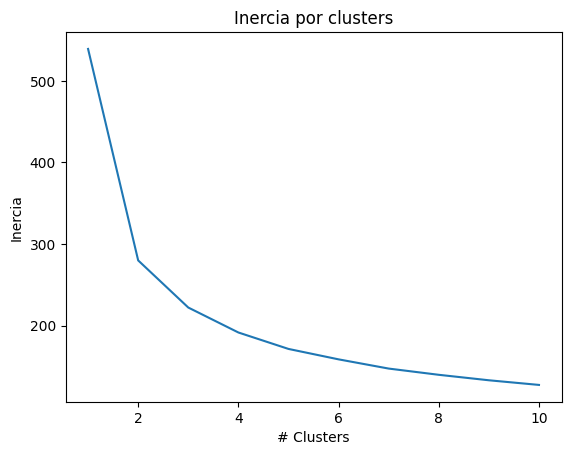

In [132]:
inertias = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, max_iter=209, n_init=35, random_state=2022)
    kmeans.fit(x_scaled2)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 11), inertias)
plt.title('Inercia por clusters')
plt.xlabel('# Clusters')
plt.ylabel('Inercia')
plt.show()

In [133]:
kmeans_per_k = [KMeans(n_clusters = k, max_iter=209, n_init=35, random_state=2022).fit(x_scaled2)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]
inertias

[539.195887878087,
 279.9927957578709,
 222.2356923618033,
 191.64656209069614,
 171.49618084073646,
 158.71928239205133,
 147.42404267368735,
 139.784370034073,
 133.07891630837062]

La métrica que determina la bondad de un modelo se llama inercia. Se calcula como la distancia cuadrática media entre cada instancia y el centroide más cercano.

El algoritmo k-means se ejecuta n_init veces y se escoge el modelo con el menor valor de inercia. Usualmente el score de un modelo sigue la regla “mayor es mejor”, por este motivo se maneja un valor negativo de inercia.

## **Gráfico de Silueta** : Selección del "K" óptimo

In [134]:
from sklearn.metrics import silhouette_score
silhouette_scores = [silhouette_score(x_scaled2, model.labels_)
                     for model in kmeans_per_k[1:]]


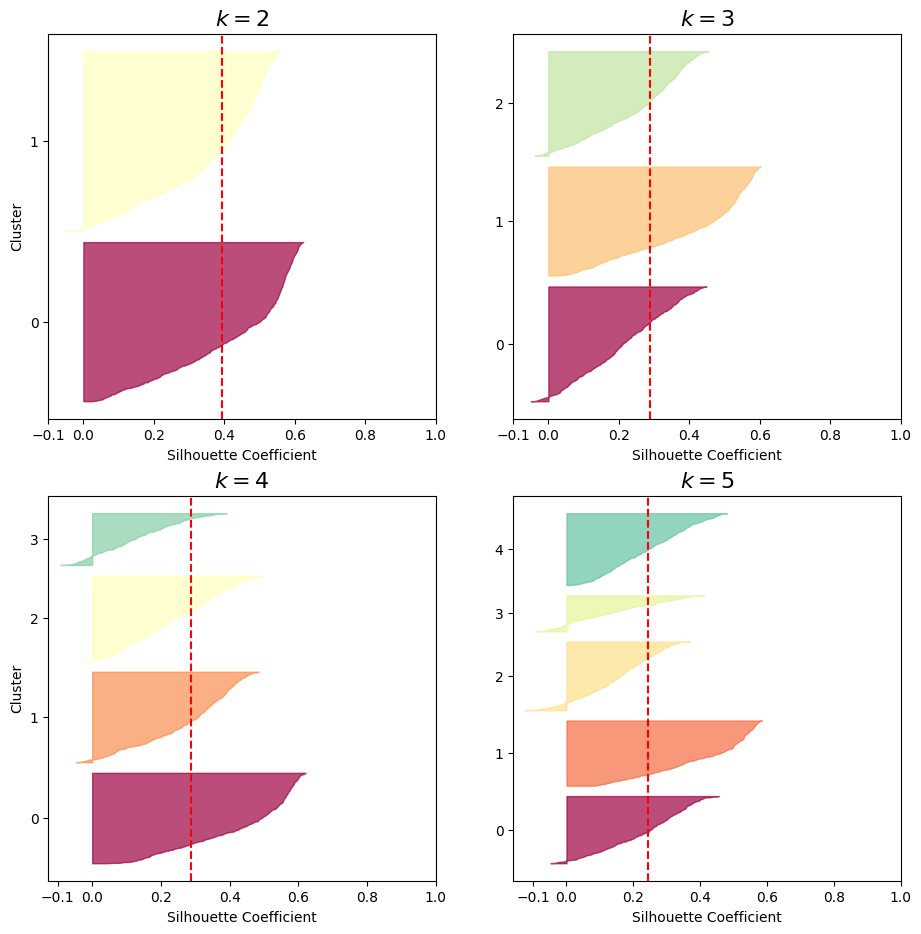

In [135]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 11))

for k in (2, 3, 4, 5):
    plt.subplot(2, 2, k - 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(x_scaled2, y_pred)

    padding = len(x_scaled2) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (2, 4):
        plt.ylabel("Cluster")

    if k in (2, 3, 4, 5):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

- Tamaños de silueta por cluster más homogéneos entre sí
- No presencia de muchos valores hacia -1
- Score de silueta promedio mayor respecto a otros k

## **Entrenamos el Modelo 1: "K-means"** (con el K óptimo)

In [136]:
param

{'max_iter': 289, 'n_clusters': 8, 'n_init': 7}

In [137]:
modelo1 = KMeans(n_clusters = 3, max_iter=209, n_init=35, random_state=2022)

In [138]:
x['Cluster_modelo1'] = modelo1.fit_predict(x_scaled2)
print(x.columns)
x.head(5)

Index(['NOTIENEAGUA', 'NOTIENEDESAGUE', 'NOTIENEELECTRICIDAD', 'NOTIENESEGURO',
       'RURAL', 'ANALFABETISMO', 'CONDISCAPACIDAD', 'PROMEDIODEHOGARES',
       'SINEQUIPOSDECOMUNICACION', 'Cluster_modelo1'],
      dtype='object')


,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION,Cluster_modelo1
s010101_CHACHAPOYAS,16.546567,21.074099,7.586676,18.150296,1.727577,8.912231,9.957348,3.0,11.504815,1
s010102_ASUNCION,2.000000,22.000000,15.000000,4.580153,44.656489,18.400000,25.190840,2.0,14.843750,1
s010103_BALSAS,54.654655,69.669670,27.627628,18.221831,68.838028,17.823640,9.066901,3.0,14.313380,0
s010104_CHETO,12.735849,16.981132,12.264151,11.059190,30.062305,9.967320,18.224299,3.0,13.948864,1
s010105_CHILIQUIN,78.431373,85.294118,34.313725,5.299145,67.863248,18.671454,7.350427,3.0,15.200243,2


In [139]:
x['Cluster_modelo1']

,Cluster_modelo1
s010101_CHACHAPOYAS,1
s010102_ASUNCION,1
s010103_BALSAS,0
s010104_CHETO,1
s010105_CHILIQUIN,2
...,...
s250302_IRAZOLA,0
s250303_CURIMANA,2
s250304_NESHUYA,0
s250305_ALEXANDER VON HUMBOLDT,1


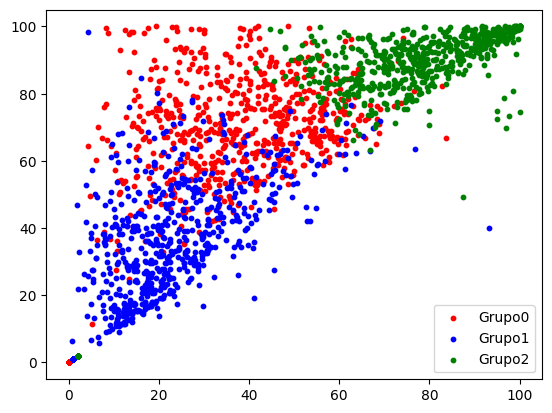

In [140]:
plt.scatter(x[x.Cluster_modelo1 == 0][['Cluster_modelo1', 'NOTIENEAGUA']], x[x.Cluster_modelo1 == 0][['Cluster_modelo1', 'NOTIENEDESAGUE']], s = 10, c = 'red', label = 'Grupo0')
plt.scatter(x[x.Cluster_modelo1 == 1][['Cluster_modelo1', 'NOTIENEAGUA']], x[x.Cluster_modelo1 == 1][['Cluster_modelo1', 'NOTIENEDESAGUE']], s = 10, c = 'blue', label = 'Grupo1')
plt.scatter(x[x.Cluster_modelo1 == 2][['Cluster_modelo1', 'NOTIENEAGUA']], x[x.Cluster_modelo1 == 2][['Cluster_modelo1', 'NOTIENEDESAGUE']], s = 10, c = 'green', label = 'Grupo2')
plt.legend()

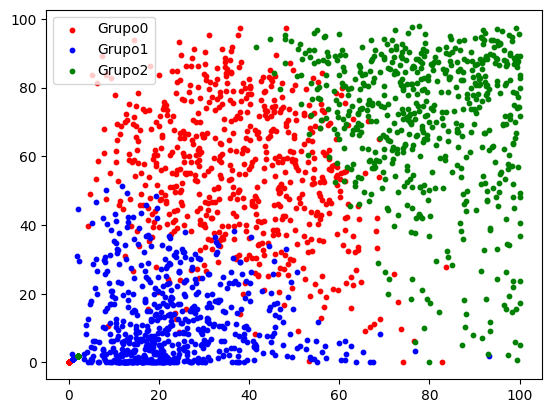

In [141]:
plt.scatter(x[x.Cluster_modelo1 == 0][['Cluster_modelo1', 'NOTIENEAGUA']], x[x.Cluster_modelo1 == 0][['Cluster_modelo1', 'RURAL']], s = 10, c = 'red', label = 'Grupo0')
plt.scatter(x[x.Cluster_modelo1 == 1][['Cluster_modelo1', 'NOTIENEAGUA']], x[x.Cluster_modelo1 == 1][['Cluster_modelo1', 'RURAL']], s = 10, c = 'blue', label = 'Grupo1')
plt.scatter(x[x.Cluster_modelo1 == 2][['Cluster_modelo1', 'NOTIENEAGUA']], x[x.Cluster_modelo1 == 2][['Cluster_modelo1', 'RURAL']], s = 10, c = 'green', label = 'Grupo2')
plt.legend()

In [142]:
# Descriptivos Cluster rojo
x[x.Cluster_modelo1 == 0].describe()

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION,Cluster_modelo1
count,646.000000,646.000000,646.000000,646.000000,646.000000,646.000000,646.000000,646.000000,646.000000,646.0
mean,37.910458,70.491184,21.767440,14.819764,55.166215,17.740610,11.441368,2.739938,14.282581,0.0
std,15.195791,14.367896,10.463936,9.666922,19.533444,5.383936,4.958385,0.591686,0.942316,0.0
min,4.375000,11.340206,1.923077,1.063830,0.000000,1.770492,1.640958,1.000000,8.098548,0.0
25%,26.135128,61.139298,14.336386,7.373032,41.474085,13.898886,7.946561,2.000000,13.724415,0.0
50%,37.873364,69.893992,20.071011,12.261133,55.985097,17.387432,10.279941,3.000000,14.273333,0.0
75%,48.973146,79.928486,27.679502,20.591843,70.454315,21.138427,13.868099,3.000000,14.794304,0.0
max,83.675464,100.000000,59.618008,58.083702,97.308828,37.574850,34.221311,5.000000,18.413866,0.0


In [143]:
# Descriptivos Cluster verde
x[x.Cluster_modelo1 == 2].describe()

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION,Cluster_modelo1
count,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.0
mean,79.129015,90.296415,36.011505,14.599726,69.544252,19.452713,10.729190,2.761054,15.069295,2.0
std,13.676474,7.625517,18.435191,10.408328,21.084130,5.613238,5.291333,0.803716,1.077562,0.0
min,41.500000,49.201278,5.228758,1.616304,0.176389,5.411499,1.688404,1.000000,10.423211,2.0
25%,69.320158,85.450638,22.512417,6.767499,58.775125,15.624377,6.900906,2.000000,14.406751,2.0
50%,78.840028,91.723889,32.257146,11.087466,74.079881,19.397633,9.752395,3.000000,14.915463,2.0
75%,91.490923,96.597356,44.736239,20.667768,86.100182,23.350004,13.451862,3.000000,15.719103,2.0
max,100.000000,100.000000,100.000000,66.555688,97.798239,40.579022,51.960784,6.000000,18.502964,2.0


In [144]:
# Descriptivos Cluster azul
x[x.Cluster_modelo1 == 1].describe()

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION,Cluster_modelo1
count,613.000000,613.000000,613.000000,613.000000,613.000000,613.000000,613.000000,613.000000,613.000000,613.0
mean,23.517044,37.631781,11.809550,22.198151,12.019920,11.499784,11.727169,2.943719,11.883001,1.0
std,13.202124,16.566371,7.727315,9.502184,11.955984,4.417742,3.969267,0.649042,2.539393,0.0
min,0.645161,5.680586,0.000000,1.923077,0.000000,3.317119,4.482759,1.000000,1.473746,1.0
25%,13.901345,24.686731,6.315726,15.286236,2.004812,8.586976,9.377497,3.000000,10.709034,1.0
50%,20.833333,36.247086,10.491563,21.906181,8.184348,10.625277,10.778603,3.000000,12.376238,1.0
75%,29.832613,49.700599,15.869803,28.878620,19.152965,13.600000,12.885090,3.000000,13.588627,1.0
max,93.157895,98.406375,58.407080,63.675958,51.365507,33.115672,30.578512,4.000000,17.108813,1.0


# **Modelo 2: "K-Prototypes"**

In [145]:
!pip install kmodes
!pip install KPrototypes

In [146]:
from kmodes.kprototypes import KPrototypes

modelo2 = KPrototypes(random_state = 2022, init = 'random', n_jobs = -1)

## **Discretizamos "SINEQUIPOSDECOMUNICACION"** : (misma amplitud y diferente frecuencia)

In [147]:
x_scaled2.head(1)

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION
s010101_CHACHAPOYAS,0.165466,0.210741,0.075867,0.181503,0.017276,0.089122,0.099573,0.4,0.115048


In [148]:
x_scaled2.SINEQUIPOSDECOMUNICACION.describe()

,SINEQUIPOSDECOMUNICACION
count,1847.000000
mean,0.137366
std,0.021514
min,0.014737
25%,0.130720
50%,0.141841
75%,0.149281
max,0.185030


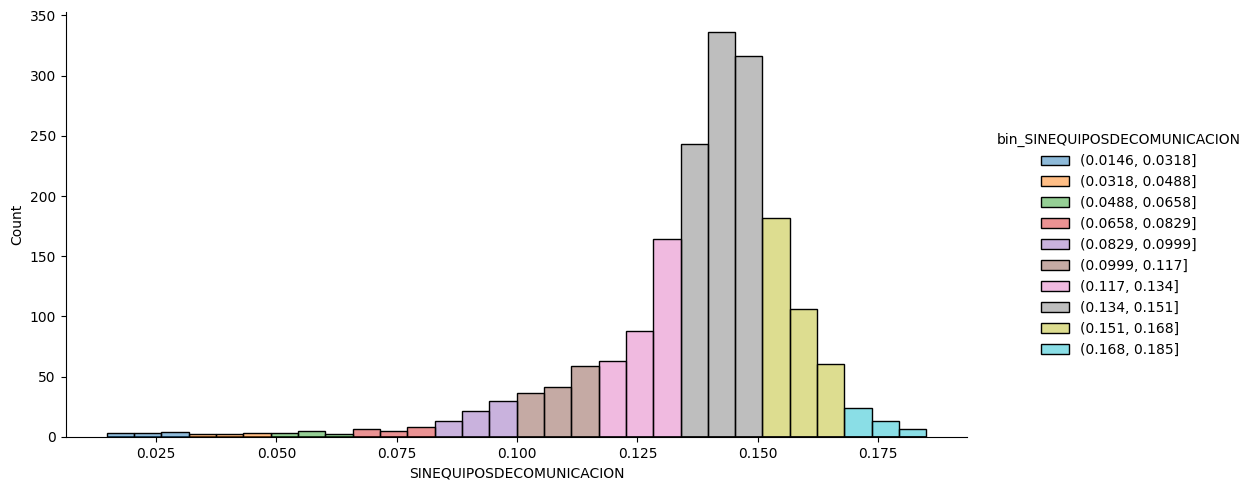

In [149]:
x_scaled2['bin_SINEQUIPOSDECOMUNICACION'] = pd.cut(x_scaled2.SINEQUIPOSDECOMUNICACION, 10)
sns.displot(x_scaled2, x='SINEQUIPOSDECOMUNICACION', hue='bin_SINEQUIPOSDECOMUNICACION', aspect=2, bins=30)

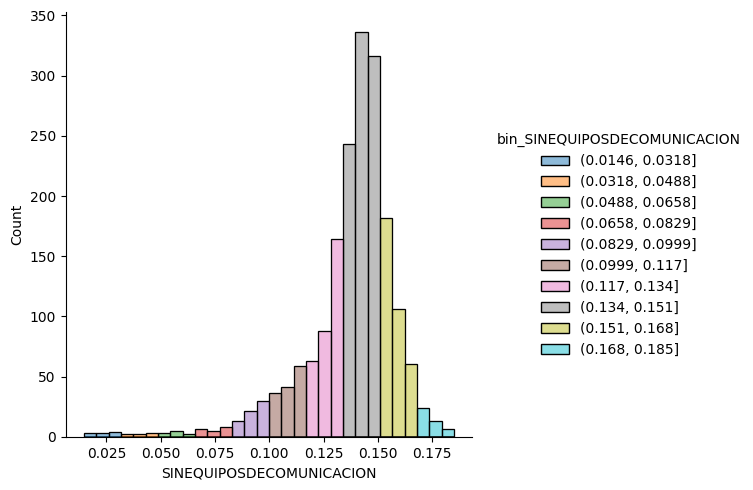

In [150]:
sns.displot(x_scaled2, x='SINEQUIPOSDECOMUNICACION', hue='bin_SINEQUIPOSDECOMUNICACION', aspect=1, bins=30)

In [151]:
x_scaled2.drop('SINEQUIPOSDECOMUNICACION', axis=1, inplace=True)

In [152]:
print(x_scaled2.dtypes)
x_scaled2.head(3)

NOTIENEAGUA                      float64
NOTIENEDESAGUE                   float64
NOTIENEELECTRICIDAD              float64
NOTIENESEGURO                    float64
RURAL                            float64
ANALFABETISMO                    float64
CONDISCAPACIDAD                  float64
PROMEDIODEHOGARES                float64
bin_SINEQUIPOSDECOMUNICACION    category
dtype: object


,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,bin_SINEQUIPOSDECOMUNICACION
s010101_CHACHAPOYAS,0.165466,0.210741,0.075867,0.181503,0.017276,0.089122,0.099573,0.4,"(0.0999, 0.117]"
s010102_ASUNCION,0.020000,0.220000,0.150000,0.045802,0.446565,0.184000,0.251908,0.2,"(0.134, 0.151]"
s010103_BALSAS,0.546547,0.696697,0.276276,0.182218,0.688380,0.178236,0.090669,0.4,"(0.134, 0.151]"


## **Identificamos posición de variables categóricas**

In [153]:
catColumnsPos = [x_scaled2.columns.get_loc(col) for col in list(x_scaled2.select_dtypes(['object', 'string', 'category']).columns)]

print('Categorical columns           : {}'.format(list(x_scaled2.select_dtypes(['object', 'string', 'category']).columns)))
print('Categorical columns position  : {}'.format(catColumnsPos))

Categorical columns           : ['bin_SINEQUIPOSDECOMUNICACION']
Categorical columns position  : [8]


**Convertimos a matriz**

In [154]:
Xmatrix = x_scaled2.to_numpy()
Xmatrix

array([[0.1654656696125085, 0.2107409925220938, 0.07586675730795377, ...,
        0.09957347571266378, 0.4000000000000001,
        Interval(0.0999, 0.117, closed='right')],
       [0.02, 0.22, 0.15, ..., 0.2519083969465649, 0.2,
        Interval(0.134, 0.151, closed='right')],
       [0.5465465465465466, 0.6966966966966965, 0.27627627627627627, ...,
        0.09066901408450705, 0.4000000000000001,
        Interval(0.134, 0.151, closed='right')],
       ...,
       [0.4665249734325186, 0.7853347502656747, 0.19341126461211477, ...,
        0.07979984198051093, 0.6000000000000001,
        Interval(0.117, 0.134, closed='right')],
       [0.34292565947242204, 0.6866506794564349, 0.18625099920063948,
        ..., 0.09421841541755889, 0.6000000000000001,
        Interval(0.134, 0.151, closed='right')],
       [0.9970717423133236, 0.9633967789165446, 0.5841874084919473, ...,
        0.06118881118881119, 0.6000000000000001,
        Interval(0.151, 0.168, closed='right')]], dtype=object)

In [155]:
Xmatrix[1,:]

array([0.02, 0.22, 0.15, 0.045801526717557266, 0.44656488549618323, 0.184,
       0.2519083969465649, 0.2, Interval(0.134, 0.151, closed='right')],
      dtype=object)

## **Gráfico del Codo** : Selección del "K" óptimo

In [156]:
param

{'max_iter': 289, 'n_clusters': 8, 'n_init': 7}

In [157]:
# optimal K using Elbow method
cost = []
for cluster in range(1, 11):
    try:
        kprototype = KPrototypes(n_clusters = cluster, max_iter= 209, n_init= 35, random_state = 2022, init = 'random', n_jobs = -1)
        kprototype.fit_predict(Xmatrix, categorical = catColumnsPos)
        cost.append(kprototype.cost_)
        print('Cluster initiation: {}'.format(cluster))
    except:
        break

Cluster initiation: 1
Cluster initiation: 2
Cluster initiation: 3
Cluster initiation: 4
Cluster initiation: 5
Cluster initiation: 6
Cluster initiation: 7
Cluster initiation: 8
Cluster initiation: 9
Cluster initiation: 10


In [158]:
df_cost = pd.DataFrame({'Cluster':range(1, 11), 'Cost':cost})
df_cost

,Cluster,Cost
0,1,618.133986
1,2,359.180812
2,3,294.558525
3,4,263.973553
4,5,239.012045
5,6,219.857950
6,7,205.587758
7,8,195.672547
8,9,188.412692
9,10,179.796142


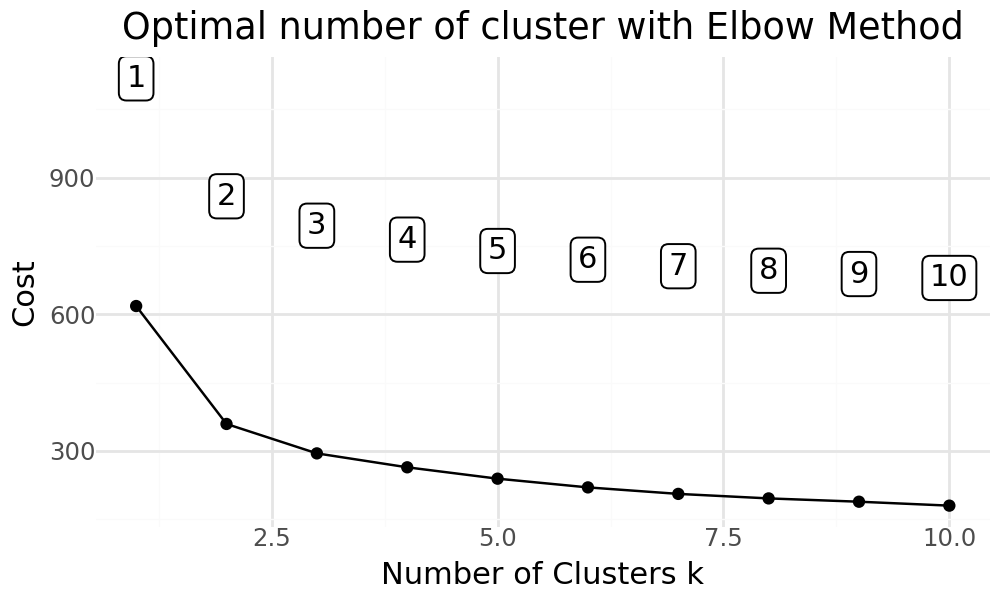

In [159]:
from plotnine import *
import plotnine

plotnine.options.figure_size = (5, 3)
(
    ggplot(data = df_cost)+
    geom_line(aes(x = 'Cluster',
                  y = 'Cost'))+
    geom_point(aes(x = 'Cluster',
                   y = 'Cost'))+
    geom_label(aes(x = 'Cluster',
                   y = 'Cost',
                   label = 'Cluster'),
               size = 11,
               nudge_y = 500) +
    labs(title = 'Optimal number of cluster with Elbow Method')+
    #xlim(0, 11.5) +
    #ylim(230, 500) +
    xlab('Number of Clusters k')+
    ylab('Cost')+
    theme_minimal()
)

In [160]:
from numba import jit, cuda
# function optimized to run on gpu
jit(target ="cuda")

<function numba.core.decorators._jit.<locals>.wrapper(func)>

In [161]:
# optimal K using Elbow method
cost = []
for cluster in range(1, 7):
    try:
        kprototype = KPrototypes(n_clusters = cluster, max_iter= 209, n_init= 35, random_state = 2022, init = 'random', n_jobs = -1)
        kprototype.fit_predict(Xmatrix, categorical = catColumnsPos)
        cost.append(kprototype.cost_)
        print('Cluster initiation: {}'.format(cluster))
    except:
        break

Cluster initiation: 1
Cluster initiation: 2
Cluster initiation: 3
Cluster initiation: 4
Cluster initiation: 5
Cluster initiation: 6


In [162]:
# results
df_cost = pd.DataFrame({'Cluster':range(1, 7), 'Cost':cost})
df_cost

,Cluster,Cost
0,1,618.133986
1,2,359.180812
2,3,294.558525
3,4,263.973553
4,5,239.012045
5,6,219.857950


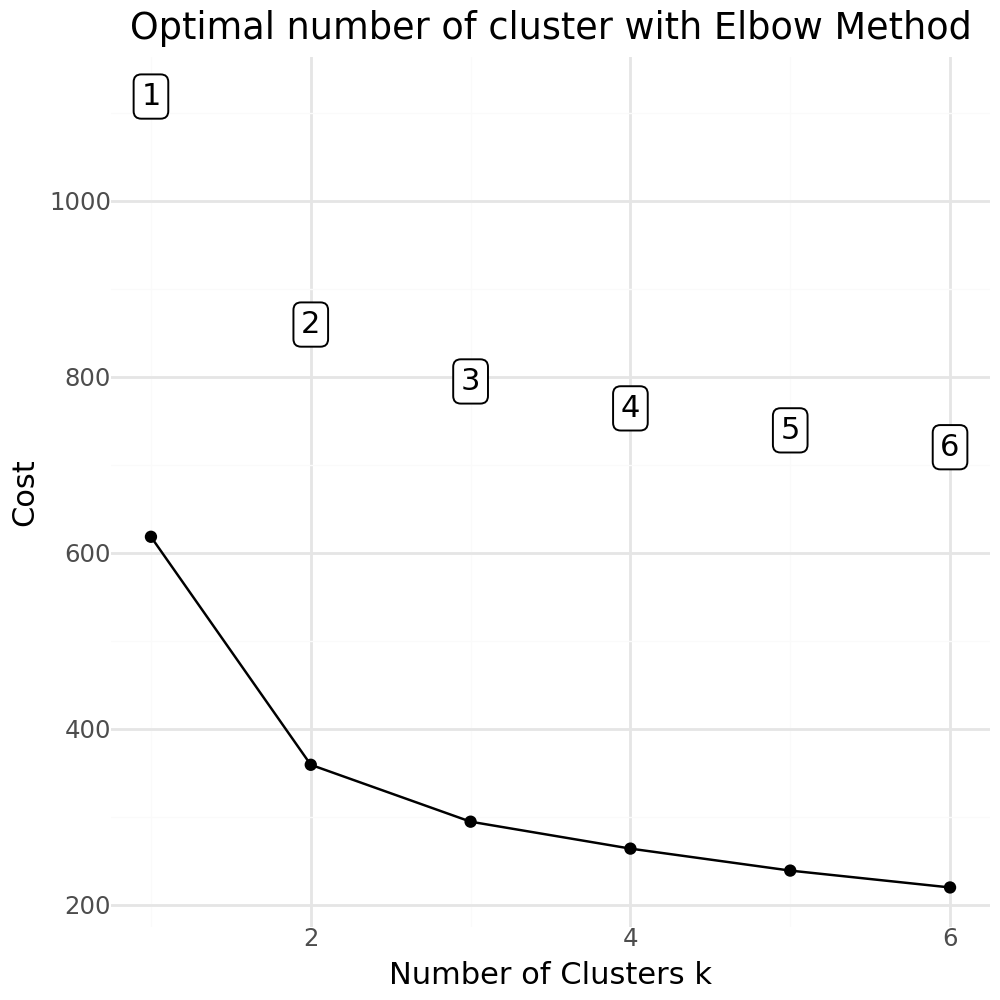

In [163]:
from plotnine import *
import plotnine

plotnine.options.figure_size = (5, 5)
(
    ggplot(data = df_cost)+
    geom_line(aes(x = 'Cluster',
                  y = 'Cost'))+
    geom_point(aes(x = 'Cluster',
                   y = 'Cost'))+
    geom_label(aes(x = 'Cluster',
                   y = 'Cost',
                   label = 'Cluster'),
               size = 11,
               nudge_y = 500) +
    labs(title = 'Optimal number of cluster with Elbow Method')+
    #xlim(0, 11.5) +
    #ylim(230, 500) +
    xlab('Number of Clusters k')+
    ylab('Cost')+
    theme_minimal()
)

## **Entrenamos el Modelo 2: "KPrototypes"** (con el K óptimo)

In [164]:
modelo2 = KPrototypes(n_clusters = 3, max_iter= 209, n_init= 35, random_state = 2022, init = 'random', n_jobs = -1)
modelo2.fit_predict(Xmatrix, categorical = catColumnsPos)

array([0, 0, 2, ..., 2, 2, 1], dtype=uint16)

Cluster centroids

In [165]:
modelo2.cluster_centroids_

array([[0.23833942400056615, 0.3708868729082871, 0.11399231613874598,
        0.22509484102357194, 0.11925513014335085, 0.11217232877419266,
        0.11456822277101493, 0.3967851099830865,
        Interval(0.117, 0.134, closed='right')],
       [0.7795869939824371, 0.9004996323026759, 0.3548500376543239,
        0.1449637796836775, 0.7012515656336612, 0.19471470357833598,
        0.10727072814506539, 0.35441176470588076,
        Interval(0.134, 0.151, closed='right')],
       [0.3670400752713908, 0.6936317760706899, 0.2177331809375207,
        0.14892523626095805, 0.5269104333438609, 0.17705080498803064,
        0.11727781380875375, 0.3397515527950326,
        Interval(0.134, 0.151, closed='right')]], dtype=object)

In [166]:
# iteration of the clusters created
modelo2.n_iter_

9

In [167]:
# cost of the clusters created
modelo2.cost_

np.float64(294.5585245401538)

In [168]:
x['Cluster_modelo2'] = modelo2.labels_
x['Cluster_modelo2']

,Cluster_modelo2
s010101_CHACHAPOYAS,0
s010102_ASUNCION,0
s010103_BALSAS,2
s010104_CHETO,0
s010105_CHILIQUIN,1
...,...
s250302_IRAZOLA,2
s250303_CURIMANA,1
s250304_NESHUYA,2
s250305_ALEXANDER VON HUMBOLDT,2


Casos por Cluster

In [169]:
x['Cluster_modelo2'].value_counts()

,count
Cluster_modelo2,
2,644
1,612
0,591


In [170]:
x.columns

Index(['NOTIENEAGUA', 'NOTIENEDESAGUE', 'NOTIENEELECTRICIDAD', 'NOTIENESEGURO',
       'RURAL', 'ANALFABETISMO', 'CONDISCAPACIDAD', 'PROMEDIODEHOGARES',
       'SINEQUIPOSDECOMUNICACION', 'Cluster_modelo1', 'Cluster_modelo2'],
      dtype='object')

In [171]:
x['Cluster_modelo2']

,Cluster_modelo2
s010101_CHACHAPOYAS,0
s010102_ASUNCION,0
s010103_BALSAS,2
s010104_CHETO,0
s010105_CHILIQUIN,1
...,...
s250302_IRAZOLA,2
s250303_CURIMANA,1
s250304_NESHUYA,2
s250305_ALEXANDER VON HUMBOLDT,2


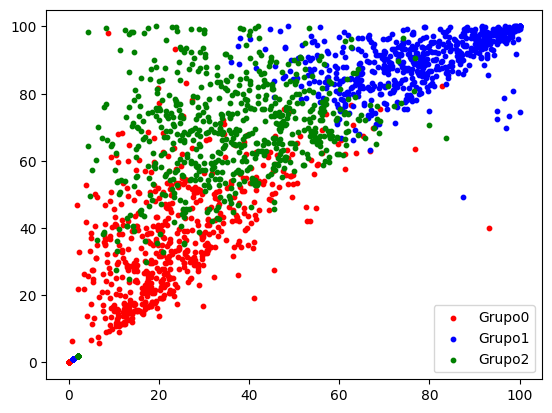

In [172]:
plt.scatter(x[x.Cluster_modelo2 == 0][['Cluster_modelo2', 'NOTIENEAGUA']], x[x.Cluster_modelo2 == 0][['Cluster_modelo2', 'NOTIENEDESAGUE']], s = 10, c = 'red', label = 'Grupo0')
plt.scatter(x[x.Cluster_modelo2 == 1][['Cluster_modelo2', 'NOTIENEAGUA']], x[x.Cluster_modelo2 == 1][['Cluster_modelo2', 'NOTIENEDESAGUE']], s = 10, c = 'blue', label = 'Grupo1')
plt.scatter(x[x.Cluster_modelo2 == 2][['Cluster_modelo2', 'NOTIENEAGUA']], x[x.Cluster_modelo2 == 2][['Cluster_modelo2', 'NOTIENEDESAGUE']], s = 10, c = 'green', label = 'Grupo2')
plt.legend()

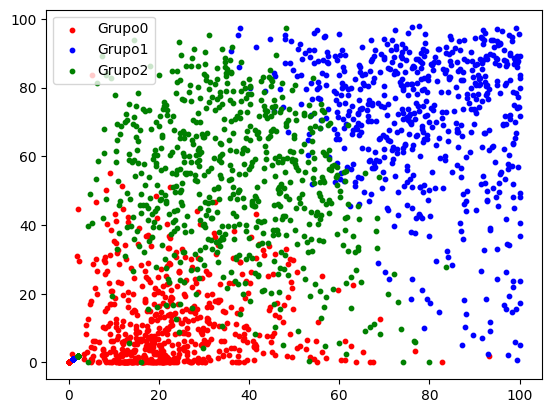

In [173]:
plt.scatter(x[x.Cluster_modelo2 == 0][['Cluster_modelo2', 'NOTIENEAGUA']], x[x.Cluster_modelo2 == 0][['Cluster_modelo2', 'RURAL']], s = 10, c = 'red', label = 'Grupo0')
plt.scatter(x[x.Cluster_modelo2 == 1][['Cluster_modelo2', 'NOTIENEAGUA']], x[x.Cluster_modelo2 == 1][['Cluster_modelo2', 'RURAL']], s = 10, c = 'blue', label = 'Grupo1')
plt.scatter(x[x.Cluster_modelo2 == 2][['Cluster_modelo2', 'NOTIENEAGUA']], x[x.Cluster_modelo2 == 2][['Cluster_modelo2', 'RURAL']], s = 10, c = 'green', label = 'Grupo2')
plt.legend()

In [174]:
3+4

7

In [175]:
import plotly.express as px
from sklearn.decomposition import PCA

datos_pca_plot = x.copy()
#datos_pca_plot['Cluster_modelo2'] = datos['Cluster_modelo2']

fig = px.scatter_3d( datos_pca_plot, x='NOTIENEAGUA', y='RURAL', z='NOTIENEDESAGUE', color='Cluster_modelo2'
)
fig.show()

In [176]:
# Descriptivos del Cluster 0
x[x.Cluster_modelo2 == 0].describe()

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION,Cluster_modelo1,Cluster_modelo2
count,591.000000,591.000000,591.000000,591.000000,591.000000,591.000000,591.000000,591.000000,591.000000,591.000000,591.0
mean,23.833942,37.088687,11.399232,22.509484,11.925513,11.217233,11.456822,2.983926,11.731066,0.947547,0.0
std,13.666139,16.599250,7.263514,9.199490,12.321354,4.164061,3.841774,0.627880,2.497704,0.223129,0.0
min,0.645161,5.680586,0.000000,1.923077,0.000000,1.770492,3.520209,1.000000,1.473746,0.000000,0.0
25%,13.880349,23.924629,6.230250,16.057659,1.844561,8.562022,9.233281,3.000000,10.638620,1.000000,0.0
50%,20.884451,35.592239,10.396040,22.580645,7.723707,10.551776,10.619130,3.000000,12.239945,1.000000,0.0
75%,30.544242,49.333943,15.521303,28.894525,18.832396,13.219198,12.513717,3.000000,13.265129,1.000000,0.0
max,93.157895,97.959184,58.407080,57.283512,83.702738,33.115672,30.578512,4.000000,17.108813,1.000000,0.0


In [177]:
# Descriptivos del Cluster 1
x[x.Cluster_modelo2 == 1].describe()

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION,Cluster_modelo1,Cluster_modelo2
count,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.0
mean,77.958699,90.049963,35.485004,14.496378,70.125157,19.471470,10.727073,2.772059,15.049275,1.911765,1.0
std,14.627472,7.767115,18.414924,10.336936,20.394754,5.557429,5.247010,0.790649,1.059398,0.411049,0.0
min,36.050725,49.201278,4.188482,1.616304,0.618779,5.411499,1.688404,1.000000,11.697002,0.000000,1.0
25%,67.163295,84.759443,22.283909,6.772718,59.877779,15.637714,6.947641,2.000000,14.370019,2.000000,1.0
50%,78.254729,91.583572,31.959149,11.043337,74.366281,19.358978,9.758946,3.000000,14.904944,2.000000,1.0
75%,90.978659,96.470905,43.668743,20.225860,85.926693,23.338804,13.427793,3.000000,15.684977,2.000000,1.0
max,100.000000,100.000000,100.000000,66.555688,97.798239,40.579022,51.960784,6.000000,18.502964,2.000000,1.0


In [178]:
# Descriptivos del Cluster 2
x[x.Cluster_modelo2 == 2].describe()

,NOTIENEAGUA,NOTIENEDESAGUE,NOTIENEELECTRICIDAD,NOTIENESEGURO,RURAL,ANALFABETISMO,CONDISCAPACIDAD,PROMEDIODEHOGARES,SINEQUIPOSDECOMUNICACION,Cluster_modelo1,Cluster_modelo2
count,644.000000,644.000000,644.000000,644.000000,644.000000,644.000000,644.000000,644.000000,644.000000,644.000000,644.0
mean,36.704008,69.363178,21.773318,14.892524,52.691043,17.705080,11.727781,2.698758,14.329746,0.091615,2.0
std,15.317525,14.436475,10.413825,9.842646,20.400944,5.385553,5.048502,0.607187,0.898579,0.304438,0.0
min,4.375000,24.773414,1.923077,1.063830,0.000000,3.671971,1.640958,1.000000,8.098548,0.000000,2.0
25%,24.851537,59.805094,14.343226,7.435624,39.008680,13.966099,8.116911,2.000000,13.786922,0.000000,2.0
50%,36.038426,68.956570,20.066141,12.178012,54.085237,17.326674,10.693083,3.000000,14.312302,0.000000,2.0
75%,47.507589,78.479523,27.614564,20.349807,68.403145,21.147486,14.420804,3.000000,14.810102,0.000000,2.0
max,83.675464,100.000000,59.618008,63.675958,97.308828,37.574850,34.221311,5.000000,18.413866,2.000000,2.0


# Contraste de Modelos

In [179]:
x[['Cluster_modelo1','Cluster_modelo2']].head(10)

,Cluster_modelo1,Cluster_modelo2
s010101_CHACHAPOYAS,1,0
s010102_ASUNCION,1,0
s010103_BALSAS,0,2
s010104_CHETO,1,0
s010105_CHILIQUIN,2,1
s010106_CHUQUIBAMBA,0,2
s010107_GRANADA,2,1
s010108_HUANCAS,1,0
s010109_LA JALCA,0,2
s010110_LEIMEBAMBA,1,0


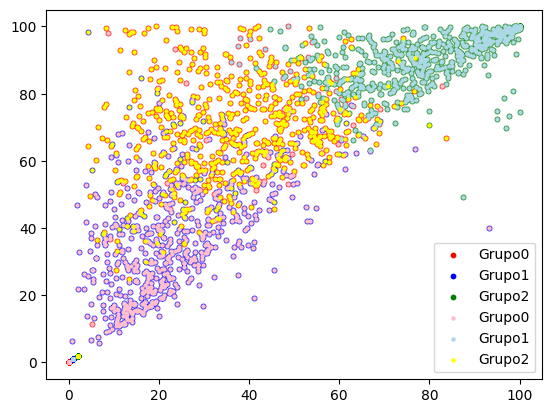

In [180]:
#Modelo1
plt.scatter(x[x.Cluster_modelo1 == 0][['Cluster_modelo1', 'NOTIENEAGUA']], x[x.Cluster_modelo1 == 0][['Cluster_modelo1', 'NOTIENEDESAGUE']], s = 10, c = 'red', label = 'Grupo0')
plt.scatter(x[x.Cluster_modelo1 == 1][['Cluster_modelo1', 'NOTIENEAGUA']], x[x.Cluster_modelo1 == 1][['Cluster_modelo1', 'NOTIENEDESAGUE']], s = 10, c = 'blue', label = 'Grupo1')
plt.scatter(x[x.Cluster_modelo1 == 2][['Cluster_modelo1', 'NOTIENEAGUA']], x[x.Cluster_modelo1 == 2][['Cluster_modelo1', 'NOTIENEDESAGUE']], s = 10, c = 'green', label = 'Grupo2')

#Modelo2
plt.scatter(x[x.Cluster_modelo2 == 0][['Cluster_modelo2', 'NOTIENEAGUA']], x[x.Cluster_modelo2 == 0][['Cluster_modelo2', 'NOTIENEDESAGUE']], s = 5, c = 'pink', label = 'Grupo0')
plt.scatter(x[x.Cluster_modelo2 == 1][['Cluster_modelo2', 'NOTIENEAGUA']], x[x.Cluster_modelo2 == 1][['Cluster_modelo2', 'NOTIENEDESAGUE']], s = 5, c = 'lightblue', label = 'Grupo1')
plt.scatter(x[x.Cluster_modelo2 == 2][['Cluster_modelo2', 'NOTIENEAGUA']], x[x.Cluster_modelo2 == 2][['Cluster_modelo2', 'NOTIENEDESAGUE']], s = 5, c = 'yellow', label = 'Grupo2')

plt.legend()

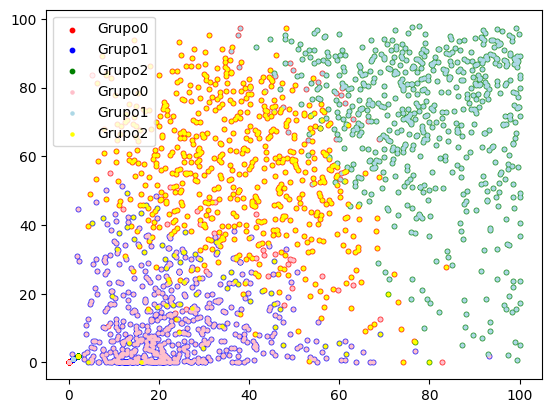

In [181]:
# Modelo1
plt.scatter(x[x.Cluster_modelo1 == 0][['Cluster_modelo1', 'NOTIENEAGUA']], x[x.Cluster_modelo1 == 0][['Cluster_modelo1', 'RURAL']], s = 10, c = 'red', label = 'Grupo0')
plt.scatter(x[x.Cluster_modelo1 == 1][['Cluster_modelo1', 'NOTIENEAGUA']], x[x.Cluster_modelo1 == 1][['Cluster_modelo1', 'RURAL']], s = 10, c = 'blue', label = 'Grupo1')
plt.scatter(x[x.Cluster_modelo1 == 2][['Cluster_modelo1', 'NOTIENEAGUA']], x[x.Cluster_modelo1 == 2][['Cluster_modelo1', 'RURAL']], s = 10, c = 'green', label = 'Grupo2')

#Modelo2
plt.scatter(x[x.Cluster_modelo2 == 0][['Cluster_modelo2', 'NOTIENEAGUA']], x[x.Cluster_modelo2 == 0][['Cluster_modelo2', 'RURAL']], s = 5, c = 'pink', label = 'Grupo0')
plt.scatter(x[x.Cluster_modelo2 == 1][['Cluster_modelo2', 'NOTIENEAGUA']], x[x.Cluster_modelo2 == 1][['Cluster_modelo2', 'RURAL']], s = 5, c = 'lightblue', label = 'Grupo1')
plt.scatter(x[x.Cluster_modelo2 == 2][['Cluster_modelo2', 'NOTIENEAGUA']], x[x.Cluster_modelo2 == 2][['Cluster_modelo2', 'RURAL']], s = 5, c = 'yellow', label = 'Grupo2')

plt.legend()